# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty. 

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [1]:
%pip install --upgrade plotly

Note: you may need to restart the kernel to use updated packages.


## Import Statements

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [4]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames? 
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [5]:
print(df_hh_income.shape)
print(df_pct_poverty.shape)
print(df_pct_completed_hs.shape)
print(df_share_race_city.shape)
print(df_fatalities.shape)

(29322, 3)
(29329, 3)
(29329, 3)
(29268, 7)
(2535, 14)


In [6]:
print(list(df_hh_income.columns))
print(list(df_pct_poverty.columns))
print(list(df_pct_completed_hs.columns))
print(list(df_share_race_city.columns))
print(list(df_fatalities.columns))

['Geographic Area', 'City', 'Median Income']
['Geographic Area', 'City', 'poverty_rate']
['Geographic Area', 'City', 'percent_completed_hs']
['Geographic area', 'City', 'share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']
['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender', 'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level', 'flee', 'body_camera']


In [7]:
print(df_hh_income.isna().sum())
print(df_pct_poverty.isna().sum())
print(df_pct_completed_hs.isna().sum())
print(df_share_race_city.isna().sum())
print(df_fatalities.isna().sum())

Geographic Area     0
City                0
Median Income      51
dtype: int64
Geographic Area    0
City               0
poverty_rate       0
dtype: int64
Geographic Area         0
City                    0
percent_completed_hs    0
dtype: int64
Geographic area          0
City                     0
share_white              0
share_black              0
share_native_american    0
share_asian              0
share_hispanic           0
dtype: int64
id                           0
name                         0
date                         0
manner_of_death              0
armed                        9
age                         77
gender                       0
race                       195
city                         0
state                        0
signs_of_mental_illness      0
threat_level                 0
flee                        65
body_camera                  0
dtype: int64


In [8]:
df_share_race_city.rename(columns={'Geographic area': 'Geographic Area'}, inplace=True)

## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate. 

## Income

In [10]:
df_hh_income['Median Income'] = pd.to_numeric(df_hh_income['Median Income'], errors='coerce')
df_hh_income['Median Income'] = df_hh_income['Median Income'].fillna(df_hh_income['Median Income'].median())

## Poverty & Education

In [11]:
df_pct_poverty['poverty_rate'] = pd.to_numeric(df_pct_poverty['poverty_rate'], errors='coerce')
df_pct_completed_hs['percent_completed_hs'] = pd.to_numeric(df_pct_completed_hs['percent_completed_hs'], errors='coerce')

## Race Data

In [12]:
cols = ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']

for col in cols:
    df_share_race_city[col] = pd.to_numeric(df_share_race_city[col], errors='coerce')

df_share_race_city[cols] = df_share_race_city[cols].fillna(df_share_race_city[cols].median())

## Fatalities Data

In [13]:
df_fatalities['age'] = pd.to_numeric(df_fatalities['age'], errors='coerce')
df_fatalities['race'] = df_fatalities['race'].fillna('Unknown')
df_fatalities['armed'] = df_fatalities['armed'].fillna('Unknown')

## Standardizing City Names

In [14]:
df_fatalities['city'] = df_fatalities['city'].str.lower().str.strip()

df_share_race_city['City'] = df_share_race_city['City'].str.lower().str.strip()
df_share_race_city['City'] = df_share_race_city['City'].str.replace(' city', '', regex=False)

# Poverty Rate in each US State

In [15]:
# Group by state
df_state_poverty = df_pct_poverty.groupby('Geographic Area')['poverty_rate'].mean()

# Sort
df_state_poverty = df_state_poverty.sort_values(ascending=False)

# Get results
print("Highest Poverty Rate State:", df_state_poverty.idxmax())
print("Lowest Poverty Rate State:", df_state_poverty.idxmin())

Highest Poverty Rate State: MS
Lowest Poverty Rate State: NJ


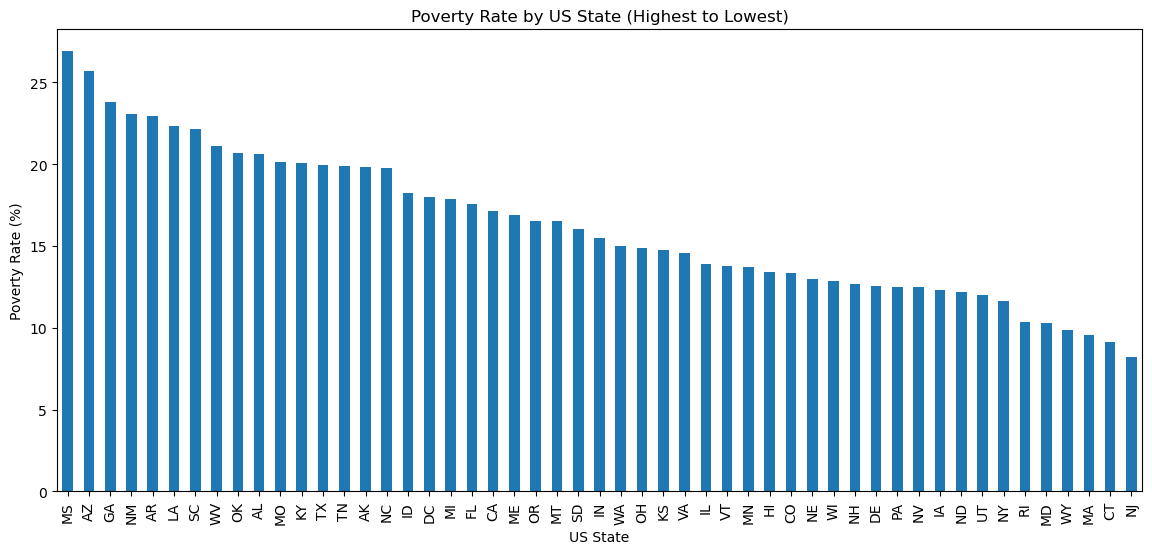

In [16]:
plt.figure(figsize=(14,6))
df_state_poverty.plot(kind='bar')

plt.title('Poverty Rate by US State (Highest to Lowest)')
plt.xlabel('US State')
plt.ylabel('Poverty Rate (%)')
plt.xticks(rotation=90)

plt.show()

# High School Graduation Rate by US State

In [17]:
df_state_hs = df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs'].mean()

In [18]:
df_state_hs = df_state_hs.sort_values(ascending=True)

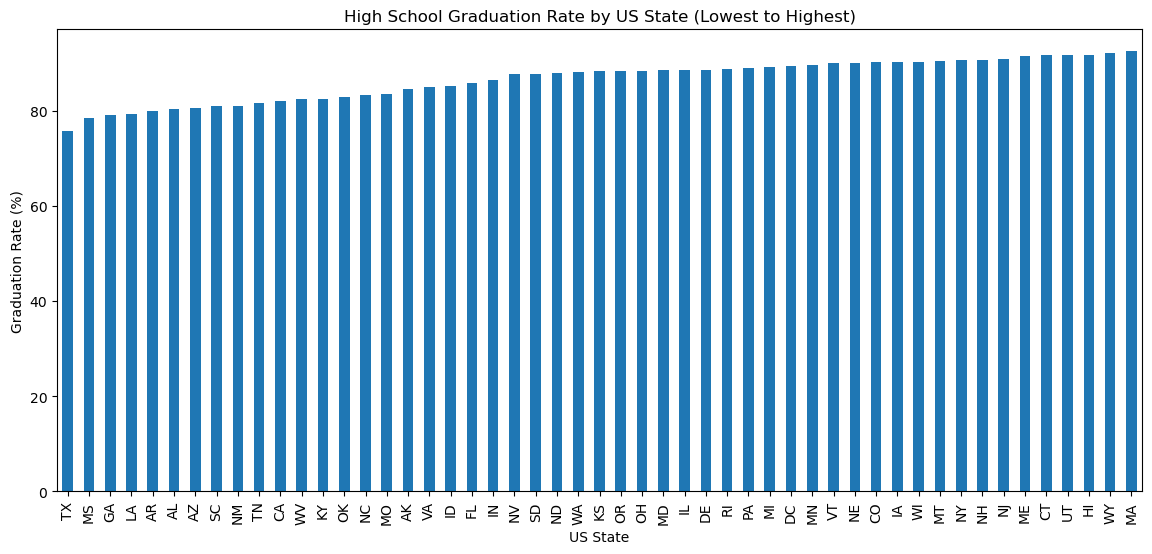

In [19]:
plt.figure(figsize=(14,6))
df_state_hs.plot(kind='bar')

plt.title('High School Graduation Rate by US State (Lowest to Highest)')
plt.xlabel('US State')
plt.ylabel('Graduation Rate (%)')
plt.xticks(rotation=90)

plt.show()

# Relationship between Poverty Rates and High School Graduation Rates 

In [20]:
# Poverty 
df_state_poverty = df_pct_poverty.groupby('Geographic Area')['poverty_rate'].mean()

# Graduation
df_state_hs = df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs'].mean()

In [21]:
df_combined = pd.concat([df_state_poverty, df_state_hs], axis=1)
df_combined.columns = ['poverty_rate', 'graduation_rate']

In [22]:
df_combined = df_combined.sort_values(by='poverty_rate')

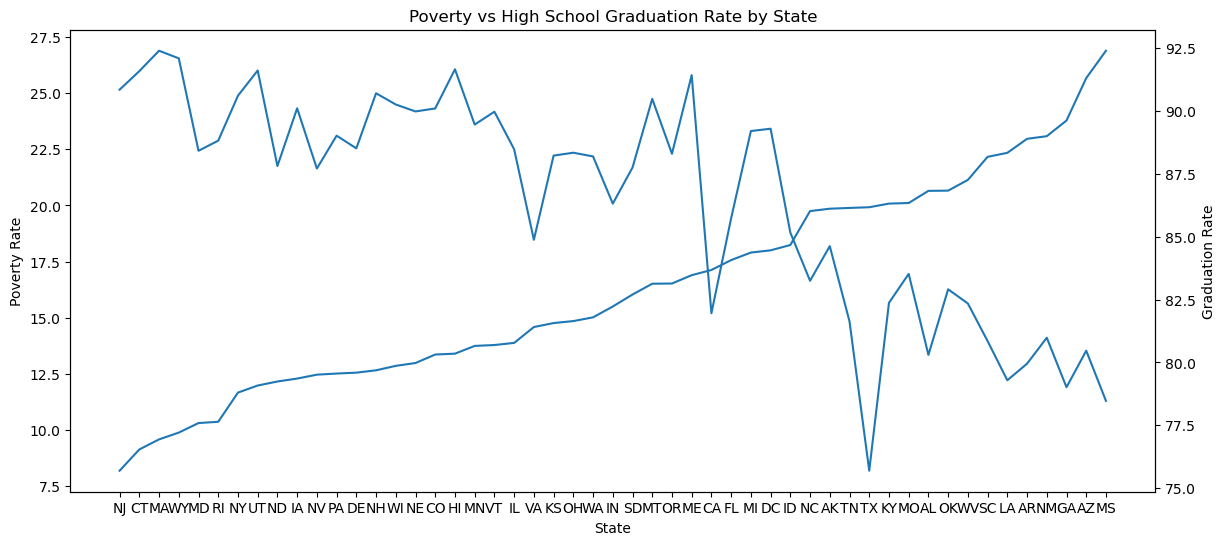

In [23]:
fig, ax1 = plt.subplots(figsize=(14,6))

# Poverty line
ax1.plot(df_combined.index, df_combined['poverty_rate'])
ax1.set_xlabel('State')
ax1.set_ylabel('Poverty Rate')

# Second axis
ax2 = ax1.twinx()
ax2.plot(df_combined.index, df_combined['graduation_rate'])
ax2.set_ylabel('Graduation Rate')

plt.title('Poverty vs High School Graduation Rate by State')
plt.xticks(rotation=90)

plt.show()

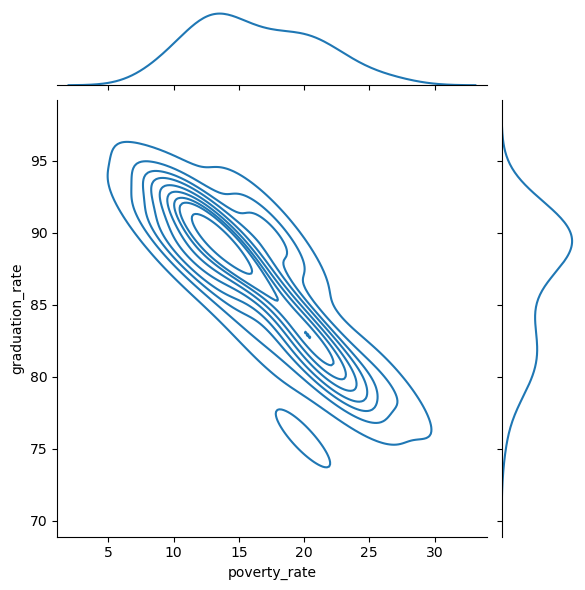

In [24]:
sns.jointplot(x='poverty_rate', y='graduation_rate', data=df_combined, kind='kde')

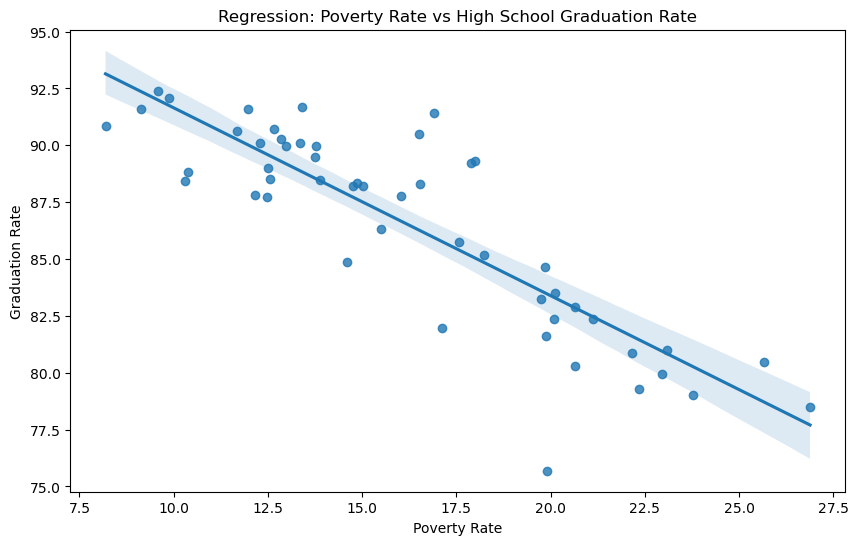

In [25]:
plt.figure(figsize=(10,6))

sns.regplot(
    x='poverty_rate',
    y='graduation_rate',
    data=df_combined
)

plt.title('Regression: Poverty Rate vs High School Graduation Rate')
plt.xlabel('Poverty Rate')
plt.ylabel('Graduation Rate')

plt.show()

# Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections. 

In [29]:
cols = ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']

for col in cols:
    df_share_race_city[col] = pd.to_numeric(df_share_race_city[col], errors='coerce')

In [30]:
df_share_race_city[cols] = df_share_race_city[cols].fillna(
    df_share_race_city[cols].median()
)

<Figure size 1400x700 with 0 Axes>

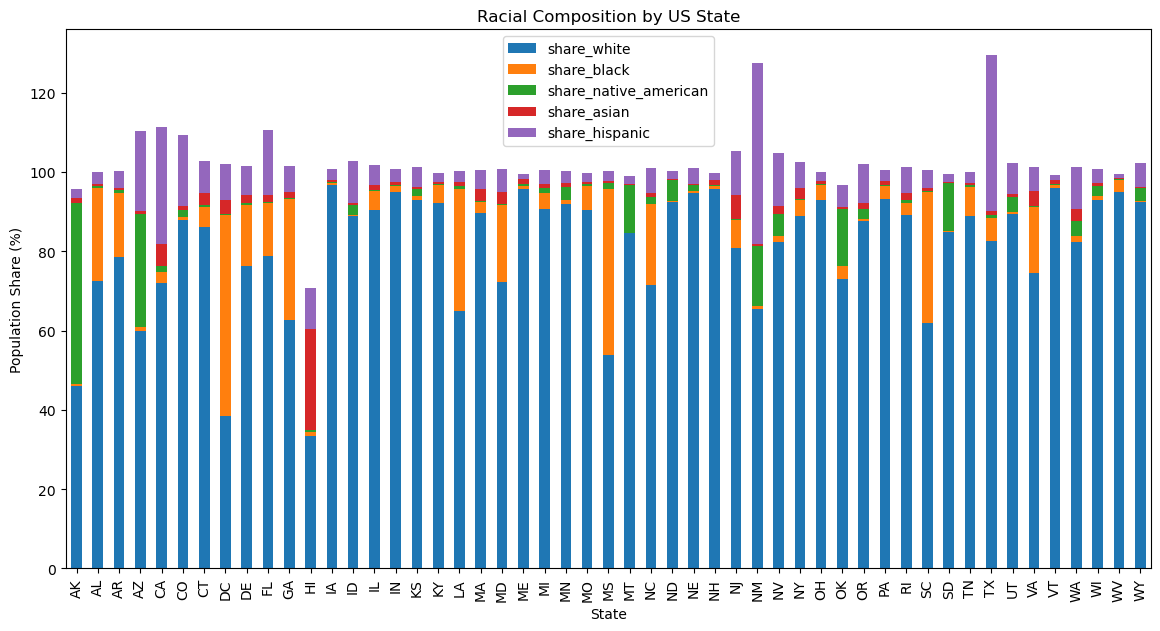

In [31]:
df_state_race = df_share_race_city.groupby('Geographic Area')[cols].mean()

plt.figure(figsize=(14,7))

df_state_race.plot(
    kind='bar',
    stacked=True,
    figsize=(14,7)
)

plt.title('Racial Composition by US State')
plt.xlabel('State')
plt.ylabel('Population Share (%)')
plt.xticks(rotation=90)

plt.show()

# People Killed by Race

In [34]:
# Clean raw data
df_fatalities['race'] = df_fatalities['race'].replace(['O', '', 'nan'], 'Unknown')
df_fatalities['race'] = df_fatalities['race'].fillna('Unknown')

# Count
race_counts = df_fatalities['race'].value_counts()

# Define mapping (MISSING PART)
race_mapping = {
    'W': 'White',
    'B': 'Black',
    'H': 'Hispanic',
    'A': 'Asian',
    'N': 'Native American',
    'Unknown': 'Unknown'
}

# Map
race_counts.index = race_counts.index.map(lambda x: race_mapping.get(x, 'Unknown'))

# Merge duplicates
race_counts = race_counts.groupby(race_counts.index).sum()

print(race_counts)

race
Asian                39
Black               618
Hispanic            423
Native American      31
Unknown             223
White              1201
Name: count, dtype: int64


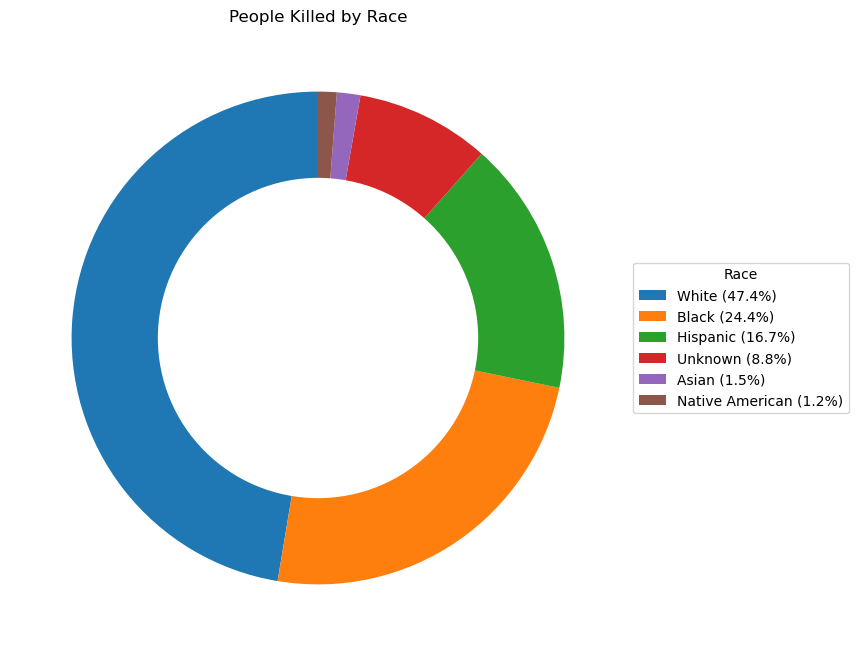

In [37]:
# Step 1: Handle missing values
df_fatalities['race'] = df_fatalities['race'].fillna('Unknown')

# Step 2: Count values
race_counts = df_fatalities['race'].value_counts()



race_counts.index = race_counts.index.map(lambda x: race_mapping.get(x, 'Unknown'))

# Step 3: Plot
plt.figure(figsize=(8,8))

wedges, _ = plt.pie(
    race_counts,
    startangle=90
)

# Donut hole
centre_circle = plt.Circle((0,0), 0.65, fc='white')
plt.gca().add_artist(centre_circle)

# Legend with percentages (BEST)
labels = [f"{label} ({value/sum(race_counts)*100:.1f}%)" 
          for label, value in zip(race_counts.index, race_counts)]

plt.legend(
    wedges,
    labels,
    title="Race",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title('People Killed by Race')
plt.show()

# Total Number of Deaths of Men and Women

In [38]:
gender_counts = df_fatalities['gender'].value_counts()
print(gender_counts)

gender
M    2428
F     107
Name: count, dtype: int64


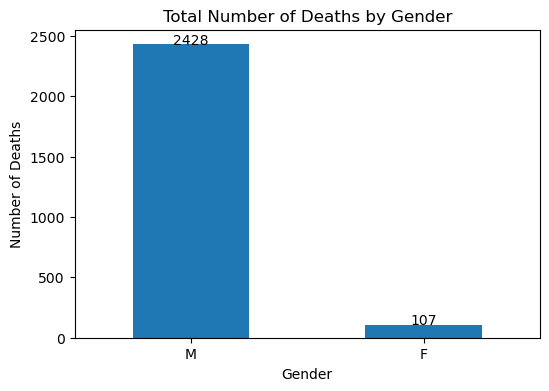

In [39]:
plt.figure(figsize=(6,4))

gender_counts.plot(kind='bar')

for i, value in enumerate(gender_counts):
    plt.text(i, value, str(value), ha='center')

plt.title('Total Number of Deaths by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Deaths')

plt.xticks(rotation=0)
plt.show()

## Age and Manner of Death

In [41]:
df_fatalities['age'] = df_fatalities['age'].fillna(df_fatalities['age'].median())

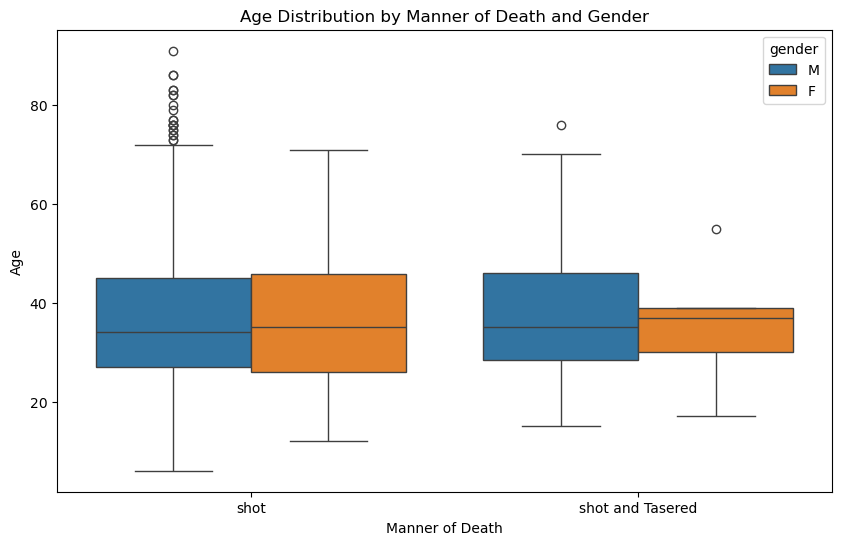

In [42]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='manner_of_death',
    y='age',
    hue='gender',
    data=df_fatalities
)

plt.title('Age Distribution by Manner of Death and Gender')
plt.xlabel('Manner of Death')
plt.ylabel('Age')

plt.show()

# Were People Armed? 

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed? 

In [43]:
df_fatalities['armed'] = df_fatalities['armed'].fillna('Unknown')
df_fatalities['armed'] = df_fatalities['armed'].str.lower()

In [44]:
def categorize_weapon(x):
    if 'gun' in x:
        return 'Gun'
    elif 'knife' in x:
        return 'Knife'
    elif 'unarmed' in x:
        return 'Unarmed'
    elif 'toy' in x:
        return 'Toy Weapon'
    elif x == 'unknown':
        return 'Unknown'
    else:
        return 'Other'

df_fatalities['weapon_category'] = df_fatalities['armed'].apply(categorize_weapon)

In [45]:
weapon_counts = df_fatalities['weapon_category'].value_counts()

weapon_percent = (weapon_counts / weapon_counts.sum()) * 100

print(weapon_counts)
print(weapon_percent)

weapon_category
Gun           1411
Other          466
Knife          374
Unarmed        171
Toy Weapon     104
Unknown          9
Name: count, dtype: int64
weapon_category
Gun          55.66
Other        18.38
Knife        14.75
Unarmed       6.75
Toy Weapon    4.10
Unknown       0.36
Name: count, dtype: float64


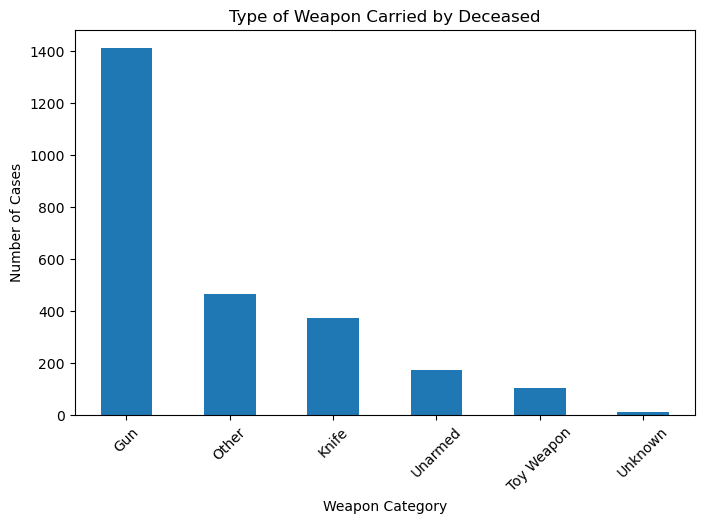

In [46]:
plt.figure(figsize=(8,5))

weapon_counts.plot(kind='bar')

plt.title('Type of Weapon Carried by Deceased')
plt.xlabel('Weapon Category')
plt.ylabel('Number of Cases')

plt.xticks(rotation=45)
plt.show()

In [47]:
gun_count = weapon_counts.get('Gun', 0)
unarmed_count = weapon_counts.get('Unarmed', 0)

print("People armed with guns:", gun_count)
print("Unarmed people:", unarmed_count)

People armed with guns: 1411
Unarmed people: 171


# How Old Were the People Killed?

Percentage of people killed were under 25 years old.  

In [48]:
df_fatalities['age'] = pd.to_numeric(df_fatalities['age'], errors='coerce')
df_age = df_fatalities.dropna(subset=['age'])
under_25 = df_age[df_age['age'] < 25].shape[0]
total = df_age.shape[0]
percentage_under_25 = (under_25 / total) * 100

print(f"Percentage of people under 25: {percentage_under_25:.2f}%")

Percentage of people under 25: 17.75%


Created a histogram and KDE plot that shows the distribution of ages of the people killed by police. 

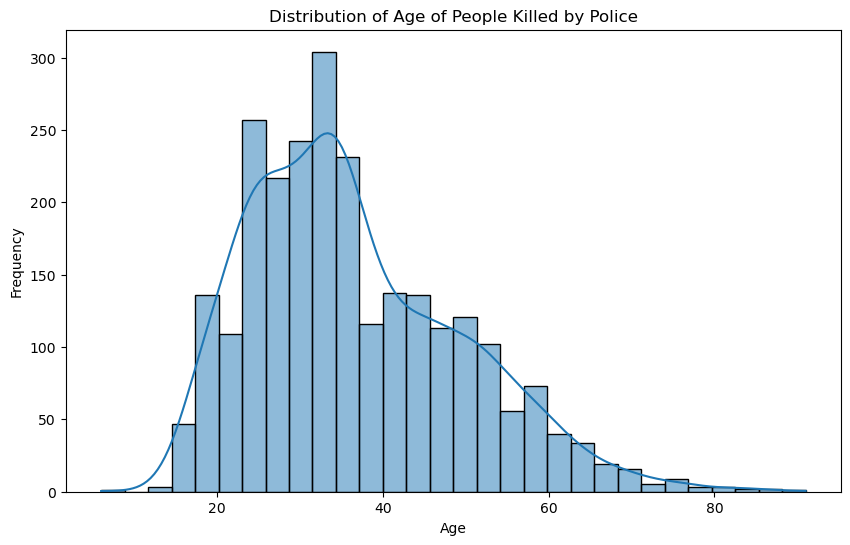

In [49]:
plt.figure(figsize=(10,6))

sns.histplot(
    df_age['age'],
    bins=30,
    kde=True
)

plt.title('Distribution of Age of People Killed by Police')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

Create a seperate KDE plot for each race. Is there a difference between the distributions? 

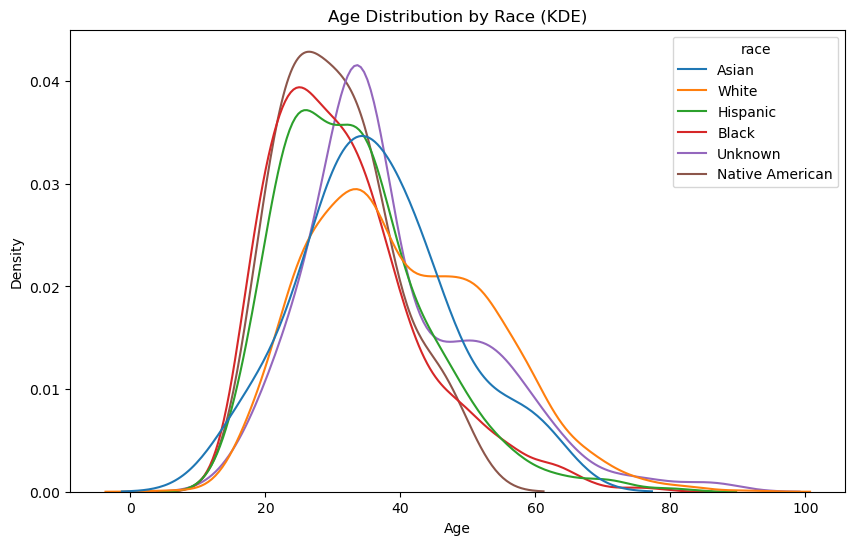

In [50]:
df_fatalities['age'] = pd.to_numeric(df_fatalities['age'], errors='coerce')
df_fatalities['race'] = df_fatalities['race'].fillna('Unknown')
df_age_race = df_fatalities.dropna(subset=['age'])
race_mapping = {
    'W': 'White',
    'B': 'Black',
    'H': 'Hispanic',
    'A': 'Asian',
    'N': 'Native American',
    'Unknown': 'Unknown'
}

df_age_race['race'] = df_age_race['race'].map(lambda x: race_mapping.get(x, 'Unknown'))

plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df_age_race,
    x='age',
    hue='race',
    common_norm=False
)

plt.title('Age Distribution by Race (KDE)')
plt.xlabel('Age')
plt.ylabel('Density')

plt.show()

# Race of People Killed

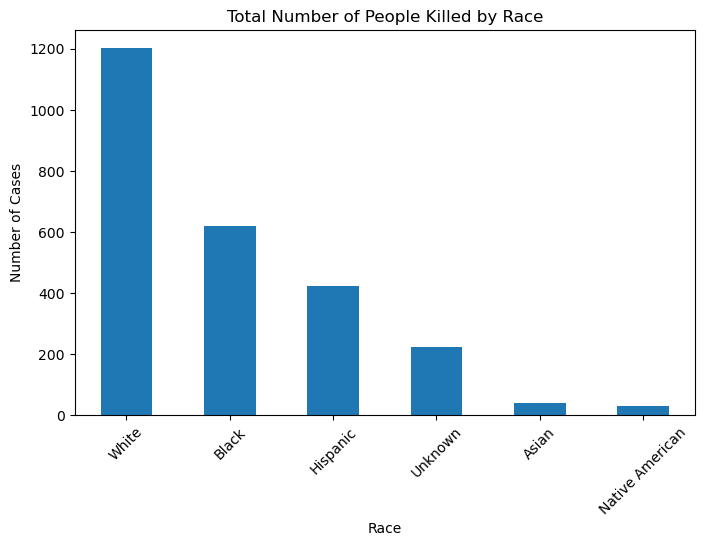

In [51]:
df_fatalities['race'] = df_fatalities['race'].fillna('Unknown')
race_mapping = {
    'W': 'White',
    'B': 'Black',
    'H': 'Hispanic',
    'A': 'Asian',
    'N': 'Native American',
    'Unknown': 'Unknown'
}

df_fatalities['race'] = df_fatalities['race'].map(lambda x: race_mapping.get(x, 'Unknown'))
race_counts = df_fatalities['race'].value_counts()


plt.figure(figsize=(8,5))

race_counts.plot(kind='bar')

plt.title('Total Number of People Killed by Race')
plt.xlabel('Race')
plt.ylabel('Number of Cases')

plt.xticks(rotation=45)
plt.show()

# Mental Illness and Police Killings

Percentage of people killed by police have been diagnosed with a mental illness?

In [52]:
mental_counts = df_fatalities['signs_of_mental_illness'].value_counts()

total = mental_counts.sum()
mental_ill = mental_counts.get(True, 0)

percentage = (mental_ill / total) * 100

print(f"Percentage with mental illness: {percentage:.2f}%")

Percentage with mental illness: 24.97%


# In Which Cities Do the Most Police Killings Take Place?

Created a chart ranking the top 10 cities with the most police killings. 

In [53]:
city_counts = df_fatalities['city'].value_counts()
top_10_cities = city_counts.head(10)
print(top_10_cities)

city
los angeles    39
phoenix        31
houston        27
chicago        25
las vegas      21
san antonio    20
columbus       19
austin         18
miami          18
st. louis      15
Name: count, dtype: int64


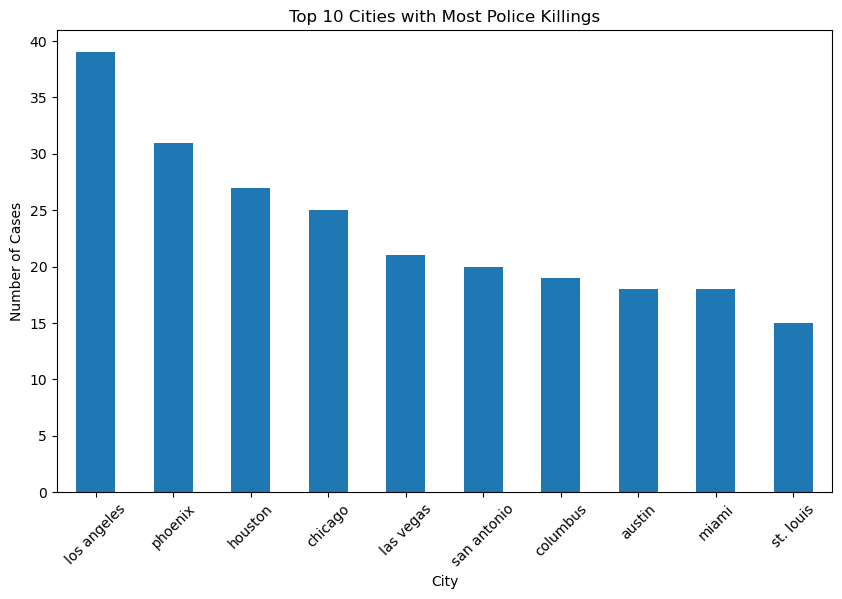

In [54]:
plt.figure(figsize=(10,6))

top_10_cities.plot(kind='bar')

plt.title('Top 10 Cities with Most Police Killings')
plt.xlabel('City')
plt.ylabel('Number of Cases')

plt.xticks(rotation=45)
plt.show()

# Rate of Death by Race. 

In [55]:
df_share_race_city['City'] = df_share_race_city['City'].str.lower().str.strip()
df_share_race_city['City'] = df_share_race_city['City'].str.replace(' city', '', regex=False)

In [56]:
df_fatalities['city'] = df_fatalities['city'].str.lower().str.strip()

In [62]:
# Top cities
top_10_cities = df_fatalities['city'].value_counts().head(10).index
df_top_cities = df_fatalities[df_fatalities['city'].isin(top_10_cities)]

# Killings distribution
race_city_killings = pd.crosstab(
    df_top_cities['city'],
    df_top_cities['race'],
    normalize='index'
) * 100

# Population
race_city_population = df_share_race_city.groupby('City')[[
    'share_white', 'share_black', 'share_native_american',
    'share_asian', 'share_hispanic'
]].mean()

race_city_population.columns = [
    'White_population', 'Black_population',
    'Native American_population', 'Asian_population', 'Hispanic_population'
]

race_city_population.index.name = 'city'

race_city_population = race_city_population.loc[
    race_city_population.index.intersection(top_10_cities)
]

# Final comparison
comparison = race_city_killings.join(race_city_population)

print(comparison)

             Asian  Black  Hispanic  Native American  Unknown  White  \
city                                                                   
austin        0.00  16.67     11.11             0.00     0.00  72.22   
chicago       0.00  84.00      4.00             0.00     4.00   8.00   
columbus      0.00  57.89      0.00             0.00    10.53  31.58   
houston       3.70  55.56     22.22             3.70     3.70  11.11   
las vegas     0.00  14.29     23.81             0.00    19.05  42.86   
los angeles   2.56  25.64     48.72             0.00     7.69  15.38   
miami         0.00  44.44     33.33             0.00     5.56  16.67   
phoenix       0.00   6.45     35.48             9.68     9.68  38.71   
san antonio   0.00  15.00     60.00             0.00    10.00  15.00   
st. louis     0.00  73.33      0.00             0.00     6.67  20.00   

             White_population  Black_population  Native American_population  \
city                                                    

# Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty? 

In [63]:
state_killings = df_fatalities['state'].value_counts().reset_index()
state_killings.columns = ['state', 'killings']

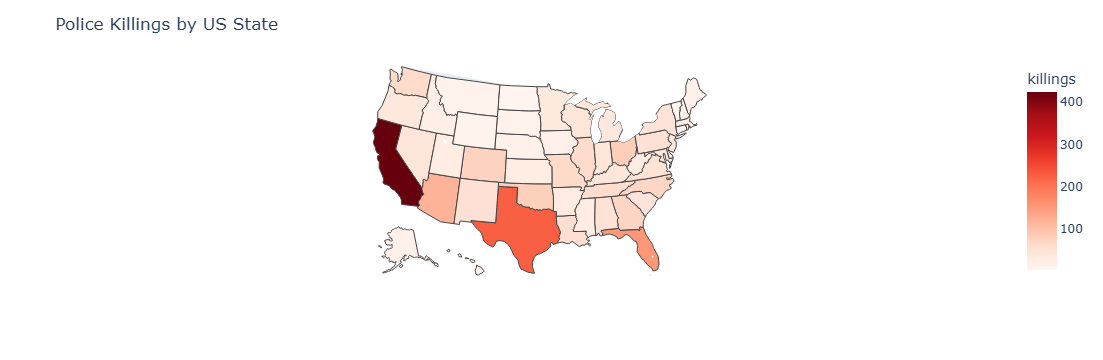

In [64]:
fig = px.choropleth(
    state_killings,
    locations='state',        # State abbreviations (CA, TX, etc.)
    locationmode='USA-states',
    color='killings',
    scope='usa',
    color_continuous_scale='Reds'
)

fig.update_layout(title='Police Killings by US State')
fig.show()

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data? 

In [66]:
df_fatalities['date'] = pd.to_datetime(df_fatalities['date'], format='%Y-%m-%d')

In [68]:
df_fatalities['year'] = df_fatalities['date'].dt.year

In [69]:
killings_per_year = df_fatalities['year'].value_counts().sort_index()
print(killings_per_year)

year
2015    991
2016    963
2017    581
Name: count, dtype: int64


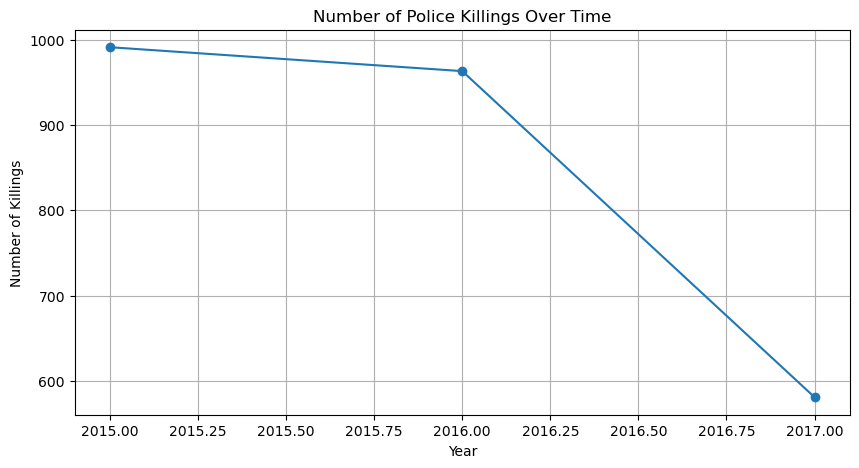

In [71]:
plt.figure(figsize=(10,5))

killings_per_year.plot(kind='line', marker='o')

plt.title('Number of Police Killings Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Killings')

plt.grid(True)
plt.show()